In [349]:
#importing libraries
import pandas as pd 
import matplotlib.pyplot as plt

In [350]:
#loading dataset
df= pd.read_csv('car_price.csv')

In [351]:
#info of the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 892 entries, 0 to 891
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   name        892 non-null    str  
 1   company     892 non-null    str  
 2   year        892 non-null    str  
 3   Price       892 non-null    str  
 4   kms_driven  840 non-null    str  
 5   fuel_type   837 non-null    str  
dtypes: str(6)
memory usage: 92.3 KB


In [352]:
#data view
df.head()

,name,company,year,Price,kms_driven,fuel_type
0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,"80,000","45,000 kms",Petrol
1,Mahindra Jeep CL550 MDI,Mahindra,2006,"4,25,000",40 kms,Diesel
2,Maruti Suzuki Alto 800 Vxi,Maruti,2018,Ask For Price,"22,000 kms",Petrol
3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,"3,25,000","28,000 kms",Petrol
4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,"5,75,000","36,000 kms",Diesel


In [353]:
#removing null values data
df.dropna(inplace= True)

In [354]:
#data info 
df.info()

<class 'pandas.DataFrame'>
Index: 837 entries, 0 to 889
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   name        837 non-null    str  
 1   company     837 non-null    str  
 2   year        837 non-null    str  
 3   Price       837 non-null    str  
 4   kms_driven  837 non-null    str  
 5   fuel_type   837 non-null    str  
dtypes: str(6)
memory usage: 94.3 KB


In [355]:
#handling price section
df= df[df['Price']!='Ask For Price']

In [356]:
#handling price section
df['Price']= df['Price'].str.replace(',','').astype(int)

In [357]:
#handling kms_driven section
df['kms_driven']= df['kms_driven'].str.replace(',','').str.replace('kms','').astype(int)

In [358]:
#handling year section
df['year']=df['year'].astype(int)

In [359]:
#handling name section
df['name']=df['name'].str.split().str[:3].str.join(' ')

In [360]:
df.info()

<class 'pandas.DataFrame'>
Index: 816 entries, 0 to 889
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        816 non-null    object
 1   company     816 non-null    str   
 2   year        816 non-null    int64 
 3   Price       816 non-null    int64 
 4   kms_driven  816 non-null    int64 
 5   fuel_type   816 non-null    str   
dtypes: int64(3), object(1), str(2)
memory usage: 54.6+ KB


In [361]:
df.loc[df['Price'].idxmax()]

name          Mahindra XUV500 W6
company                 Mahindra
year                        2014
Price                    8500003
kms_driven                 45000
fuel_type                 Diesel
Name: 562, dtype: object

In [362]:
#handling the outlier in kms section
df.loc[df['kms_driven'].idxmax()]
df= df[df['kms_driven']<400000]

In [363]:
#handling the outlier in price section
df= df[df['Price']<3000000]

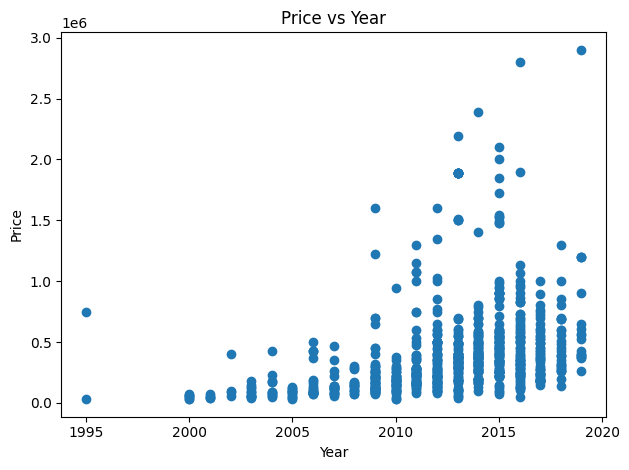

In [364]:
#Price vs Year
plt.scatter(df['year'], df['Price'])
plt.title('Price vs Year')
plt.xlabel('Year')
plt.ylabel('Price')
plt.tight_layout()

Resale Price increases with Year

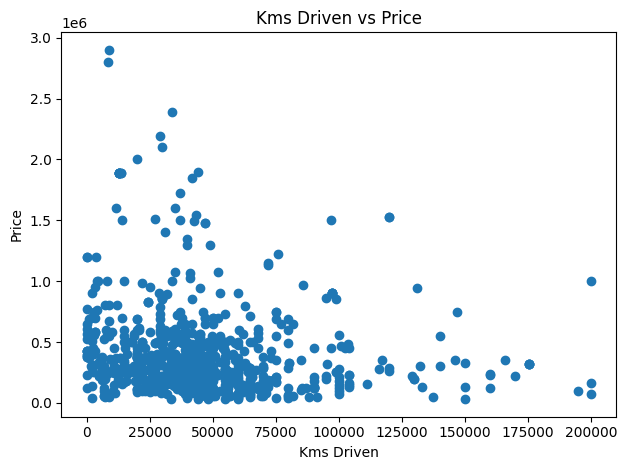

In [365]:
#Kms_driven vs Price
plt.scatter(df['kms_driven'], df['Price'])
plt.title('Kms Driven vs Price')
plt.xlabel('Kms Driven')
plt.ylabel('Price')     
plt.tight_layout()

Vehicles with less distance traveled, have more Resale Price.

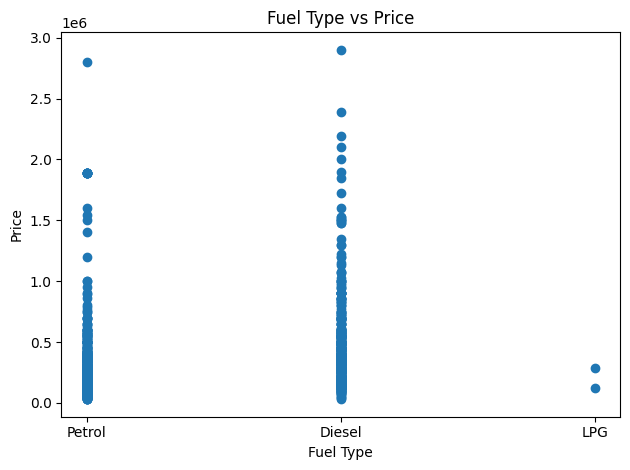

In [366]:
#fuel type vs price
plt.scatter(df['fuel_type'], df['Price'])
plt.title('Fuel Type vs Price')
plt.xlabel('Fuel Type')
plt.ylabel('Price')
plt.tight_layout()

Diesel vehicles have more Resale Price. 

In [ ]:
#importing libraries for model building
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


In [368]:
#input & output columns
X= df.drop('Price', axis=1)
y=df['Price']

In [369]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=124, shuffle=True, test_size=0.15)

In [370]:
#categorical and numerical columns
cat_cols= ['name','company', 'fuel_type']
num_cols=['year','kms_driven']

In [371]:
#Preprocessing for Distance based models
distance_preprocessor= ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

In [372]:
#Preprocessing for Tree based models
tree_preprocessor= ColumnTransformer([
    ('num', 'passthrough', num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

In [373]:
#Pipelines for different models

#linear regression
lr_pipeline= Pipeline([
    ('preprocessor', distance_preprocessor),
    ('model', LinearRegression())
])

In [374]:
#KNN
knn_pipeline= Pipeline([
    ('preprocessor', distance_preprocessor),
    ('model', KNeighborsRegressor())
])

In [375]:
#SVM
svm_pipeline= Pipeline([
    ('preprocessor', distance_preprocessor),
    ('model', SVR())
])

In [376]:
#Decision Tree
dt_pipeline= Pipeline([
    ('preprocessor', tree_preprocessor),
    ('model', DecisionTreeRegressor(random_state=124))
])

In [377]:
#Random Forest
rf_pipeline= Pipeline([
    ('preprocessor', tree_preprocessor),
    ('model', RandomForestRegressor(random_state=124))
])

In [378]:
#XG BOOST
xgb_pipeline= Pipeline([
    ('preprocessor', tree_preprocessor),
    ('model', XGBRegressor(random_state= 124))
])

In [379]:
#training the models

lr_pipeline.fit(X_train, y_train)
knn_pipeline.fit(X_train, y_train)
svm_pipeline.fit(X_train, y_train)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [380]:
dt_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train) 
xgb_pipeline.fit(X_train, y_train)  

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [381]:
#predictions
lr_pred= lr_pipeline.predict(X_test)
knn_pred= knn_pipeline.predict(X_test)
svm_pred= svm_pipeline.predict(X_test)

dt_pred= dt_pipeline.predict(X_test)
rf_pred= rf_pipeline.predict(X_test)
xgb_pred= xgb_pipeline.predict(X_test)


In [382]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

models={
    "Linear Regression": lr_pred,
    "KNN": knn_pred,
    "SVM": svm_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "XG Boost": xgb_pred
}

for name , pred in models.items():
    
    r2= r2_score(y_test, pred)
    mae= mean_absolute_error(y_test, pred)
    mse= mean_squared_error(y_test, pred)
    rsme= np.sqrt(mse)
    
    print(f"{name}")
    print(f"R2 Score: {r2}")
    print(f"MAE: {mae}")
    print(f"MSE: {mse}")
    print(f"RSME: {rsme}")
    print("-"*40)

Linear Regression
R2 Score: 0.858530244357473
MAE: 68641.73870199229
MSE: 14320713684.68967
RSME: 119669.18435708364
----------------------------------------
KNN
R2 Score: 0.8115975243043143
MAE: 90050.96721311475
MSE: 19071623469.416397
RSME: 138100.04876688638
----------------------------------------
SVM
R2 Score: -0.03432377579372092
MAE: 197734.53227309263
MSE: 104702624127.21906
RSME: 323577.84863494453
----------------------------------------
Decision Tree
R2 Score: 0.7568340258086983
MAE: 81909.53415300546
MSE: 24615228028.325363
RSME: 156892.40908445942
----------------------------------------
Random Forest
R2 Score: 0.9009539912938722
MAE: 62918.28487236534
MSE: 10026238653.2698
RSME: 100131.1073207013
----------------------------------------
XG Boost
R2 Score: 0.852009117603302
MAE: 73308.7421875
MSE: 14980832256.0
RSME: 122396.21013740581
----------------------------------------


In [383]:
#saving the best model
import joblib
joblib.dump(rf_pipeline, 'car_price_rf_model.pkl')

['car_price_rf_model.pkl']

In [384]:
#saving clean dataset
clean_dataset= df.to_csv('clean_car_price_data.csv', index= False)